# 04 — Elliptic Bitcoin Dataset Deneyi

**Amaç:** Modelin farklı bir domain'de (Bitcoin fraud) de çalıştığını göstermek.

Elliptic zaten homojen graph formatında geliyor, bu yüzden:
- GCN baseline direkt çalışır
- Hybrid model için tek node type'lı hetero graph'a çeviririz

In [5]:
# Colab setup — run once
import os, sys

if 'google.colab' in str(get_ipython()):
    # Mount Drive for data
    from google.colab import drive
    drive.mount('/content/drive')

    # Clone repo if not present
    if not os.path.exists('/content/graduation-p'):
        !git clone https://github.com/berk0vic/graduation-p.git /content/graduation-p
    os.chdir('/content/graduation-p/notebooks')
    sys.path.insert(0, '/content/graduation-p')

    # Link data from Drive
    import subprocess
    os.makedirs('../data/raw/elliptic', exist_ok=True)
    subprocess.run(['ln', '-sfn',
        '/content/drive/MyDrive/graduation-p/data/raw/elliptic/elliptic_bitcoin_dataset',
        '../data/raw/elliptic/elliptic_bitcoin_dataset'], check=True)
    print('Drive linked.')
else:
    print('Running locally.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive linked.


In [6]:
import sys
if 'google.colab' in str(get_ipython()):
    !pip install -q torch_geometric pyyaml scikit-learn xgboost
    print('Done')

Done


In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


## 1. Veri Yükleme

In [8]:
from src.data.elliptic_loader import build_pyg_graph

graph = build_pyg_graph()

print(f'Nodes: {graph.x.shape[0]:,}')
print(f'Features: {graph.x.shape[1]}')
print(f'Edges: {graph.edge_index.shape[1]:,}')
print()

# Etiket dağılımı
labeled_mask = graph.y >= 0  # -1 = unknown, bunları eğitimde kullanmayacağız
y_labeled = graph.y[labeled_mask]
n_illicit = (y_labeled == 1).sum().item()
n_licit = (y_labeled == 0).sum().item()
n_unknown = (graph.y == -1).sum().item()

print(f'Labeled: {len(y_labeled):,} (illicit: {n_illicit:,}, licit: {n_licit:,})')
print(f'Unknown: {n_unknown:,}')
print(f'Fraud oranı (labeled): {100*n_illicit/len(y_labeled):.1f}%')

Nodes: 203,769
Features: 166
Edges: 234,355

Labeled: 46,564 (illicit: 4,545, licit: 42,019)
Unknown: 157,205
Fraud oranı (labeled): 9.8%


## 2. Train/Test Split

In [9]:
# Labeled node'ları train / val / test'e böl (70 / 15 / 15)
from sklearn.model_selection import train_test_split

labeled_indices = labeled_mask.nonzero(as_tuple=True)[0].numpy()
y_labeled_np = y_labeled.numpy()

# First split: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    labeled_indices, test_size=0.30, stratify=y_labeled_np, random_state=42
)
y_temp = graph.y[temp_idx].numpy()

# Second split: 50/50 of temp → val and test (each 15%)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y_temp, random_state=42
)

train_mask = torch.zeros(graph.x.shape[0], dtype=torch.bool)
val_mask   = torch.zeros(graph.x.shape[0], dtype=torch.bool)
test_mask  = torch.zeros(graph.x.shape[0], dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

print(f'Train: {train_mask.sum().item():,} (fraud: {graph.y[train_mask].sum().item():,})')
print(f'Val:   {val_mask.sum().item():,}   (fraud: {graph.y[val_mask].sum().item():,})')
print(f'Test:  {test_mask.sum().item():,}  (fraud: {graph.y[test_mask].sum().item():,})')


Train: 32,594 (fraud: 3,181)
Val:   6,985   (fraud: 682)
Test:  6,985  (fraud: 682)


## 3. GCN Baseline

In [10]:
from src.models.baselines import GCNBaseline
from src.training.losses import focal_loss
from src.evaluation.metrics import compute_metrics, print_report

gcn = GCNBaseline(in_channels=graph.x.shape[1], hidden=64, out=32).to(device)
optimizer = torch.optim.Adam(gcn.parameters(), lr=0.001, weight_decay=1e-4)

x_dev = graph.x.to(device)
edge_dev = graph.edge_index.to(device)
y_dev = graph.y.float().to(device)

best_state = None
best_loss = float('inf')

for epoch in range(1, 101):
    gcn.train()
    optimizer.zero_grad()
    logits = gcn(x_dev, edge_dev)
    loss = focal_loss(logits[train_mask.to(device)], y_dev[train_mask.to(device)])
    loss.backward()
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in gcn.state_dict().items()}

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | loss: {loss.item():.4f}')

gcn.load_state_dict(best_state)

# Test
gcn.eval()
with torch.no_grad():
    scores = torch.sigmoid(gcn(x_dev, edge_dev)).cpu().numpy()

test_y = graph.y[test_mask].numpy()
test_scores = scores[test_mask.numpy()]

print('\n=== GCN Baseline (Elliptic) ===')
gcn_metrics = compute_metrics(test_y, test_scores)
print_report(test_y, test_scores)

Epoch  20 | loss: 0.0309
Epoch  40 | loss: 0.0273
Epoch  60 | loss: 0.0256
Epoch  80 | loss: 0.0242
Epoch 100 | loss: 0.0230

=== GCN Baseline (Elliptic) ===

--- Fraud Detection Metrics (threshold=0.512) ---
  threshold           : 0.5123
  f1_fraud            : 0.6180
  recall_fraud        : 0.6833
  precision_fraud     : 0.5642
  roc_auc             : 0.9242
  avg_precision       : 0.6126

  Confusion Matrix:
[[5943  360]
 [ 216  466]]


## 3b. XGBoost Baseline (tabular, no graph)

In [11]:
from src.models.baselines import get_xgboost
from src.evaluation.metrics import compute_metrics, print_report

# Raw features (no graph structure)
X = graph.x.numpy()
y_all = graph.y.numpy()

X_train = X[train_mask.numpy()]
y_train = y_all[train_mask.numpy()]
X_test  = X[test_mask.numpy()]
y_test  = y_all[test_mask.numpy()]

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
spw = n_neg / n_pos
print(f'scale_pos_weight: {spw:.1f}')

xgb = get_xgboost(scale_pos_weight=spw)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

xgb_scores = xgb.predict_proba(X_test)[:, 1]
print('\n=== XGBoost Baseline (Elliptic) ===')
xgb_metrics = compute_metrics(y_test, xgb_scores)
print_report(y_test, xgb_scores)


scale_pos_weight: 9.2
[0]	validation_0-aucpr:0.92136


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:10:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-aucpr:0.97535
[200]	validation_0-aucpr:0.98137
[300]	validation_0-aucpr:0.98466
[400]	validation_0-aucpr:0.98594
[499]	validation_0-aucpr:0.98718

=== XGBoost Baseline (Elliptic) ===

--- Fraud Detection Metrics (threshold=0.409) ---
  threshold           : 0.4089
  f1_fraud            : 0.9642
  recall_fraud        : 0.9487
  precision_fraud     : 0.9803
  roc_auc             : 0.9972
  avg_precision       : 0.9872

  Confusion Matrix:
[[6290   13]
 [  35  647]]


## 4. Hybrid GAT+VAE (Elliptic)

Elliptic homojen graph. Hybrid model için tek node type'lı HeteroData'ya çeviriyoruz.

In [12]:
from torch_geometric.data import HeteroData
from src.models.hybrid_model import HybridGATVAE
import yaml

# Homojen graph'ı tek-tipli hetero graph'a çevir
hetero = HeteroData()
hetero['transaction'].x = graph.x
hetero['transaction'].y = graph.y
hetero['transaction'].train_mask = train_mask
hetero['transaction'].val_mask   = val_mask
hetero['transaction'].test_mask  = test_mask
hetero['transaction', 'linked_to', 'transaction'].edge_index = graph.edge_index

print('HeteroData:')
print(f'  Node types: {hetero.node_types}')
print(f'  Edge types: {hetero.edge_types}')
print(f'  Transaction features: {hetero["transaction"].x.shape}')


HeteroData:
  Node types: ['transaction']
  Edge types: [('transaction', 'linked_to', 'transaction')]
  Transaction features: torch.Size([203769, 166])


In [13]:
with open('../configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

in_channels = {'transaction': graph.x.shape[1]}

model = HybridGATVAE(
    metadata=hetero.metadata(),
    in_channels=in_channels,
    raw_txn_dim=graph.x.shape[1],
    gat_hidden=cfg['model']['gat_hidden'],
    gat_out=cfg['model']['gat_out'],
    gat_heads=cfg['model']['gat_heads'],
    gat_layers=cfg['model']['gat_layers'],
    vae_latent=cfg['model']['vae_latent'],
    vae_hidden=cfg['model']['vae_hidden'],
    dropout=cfg['model']['dropout'],
)

print(f'Toplam parametre: {sum(p.numel() for p in model.parameters()):,}')


Toplam parametre: 291,689


In [14]:
from src.training.trainer import Trainer

trainer = Trainer(
    model=model,
    lr=cfg['training']['lr'],
    weight_decay=cfg['training']['weight_decay'],
    lambda1=cfg['training']['lambda1'],
    lambda2=cfg['training']['lambda2'],
    focal_alpha=cfg['training']['focal_alpha'],
    focal_gamma=cfg['training']['focal_gamma'],
    device=str(device),
)

print(f'Eğitim başlıyor... (100 epoch)')
history = trainer.fit(hetero, val_data=hetero, epochs=100)
print('Eğitim tamamlandı!')


Eğitim başlıyor... (100 epoch)
PHASE 1: VAE Pre-training
[VAE Phase 1] Epoch  10 | recon: 6.2274 | kl: 0.7485
[VAE Phase 1] Epoch  20 | recon: 3.5148 | kl: 5.4278
[VAE Phase 1] Epoch  30 | recon: 2.6735 | kl: 11.4570
[VAE Phase 1] Epoch  40 | recon: 2.2297 | kl: 5.9574
[VAE Phase 1] Epoch  50 | recon: 1.9547 | kl: 5.1388
[VAE Phase 1] Done. Final recon: 1.9547

PHASE 2: End-to-end training (differential LR)
Epoch   5 | cls: 0.0478 | recon: 1.9148 | val: 0.6397 | val_recon: 1.8197
Epoch  10 | cls: 0.0431 | recon: 1.8999 | val: 0.6278 | val_recon: 1.8057
Epoch  15 | cls: 0.0409 | recon: 1.8859 | val: 0.6188 | val_recon: 1.7926
Epoch  20 | cls: 0.0390 | recon: 1.8731 | val: 0.6115 | val_recon: 1.7797
Epoch  25 | cls: 0.0382 | recon: 1.8606 | val: 0.6051 | val_recon: 1.7678
Epoch  30 | cls: 0.0375 | recon: 1.8487 | val: 0.5994 | val_recon: 1.7578
Epoch  35 | cls: 0.0367 | recon: 1.8420 | val: 0.5946 | val_recon: 1.7489
Epoch  40 | cls: 0.0367 | recon: 1.8308 | val: 0.5900 | val_recon: 1.74

In [15]:
# Hybrid model test sonuçları
eval_result = trainer.evaluate(hetero)
hybrid_scores = eval_result['fraud_scores'].numpy()

hybrid_test_scores = hybrid_scores[test_mask.numpy()]

print('=== Hybrid GAT+VAE (Elliptic) ===')
hybrid_metrics = compute_metrics(test_y, hybrid_test_scores)
print_report(test_y, hybrid_test_scores)

=== Hybrid GAT+VAE (Elliptic) ===

--- Fraud Detection Metrics (threshold=0.443) ---
  threshold           : 0.4434
  f1_fraud            : 0.5719
  recall_fraud        : 0.7522
  precision_fraud     : 0.4613
  roc_auc             : 0.8941
  avg_precision       : 0.5652

  Confusion Matrix:
[[5704  599]
 [ 169  513]]


## 5. Karşılaştırma

            Model  F1 (Fraud)  Recall (Fraud)  Precision (Fraud)  AUC-ROC
XGBoost (tabular)    0.964232        0.948680           0.980303 0.997219
     GCN Baseline    0.618037        0.683284           0.564165 0.924160
   Hybrid GAT+VAE    0.571906        0.752199           0.461331 0.894118

Kaydedildi: results/tables/elliptic_results.csv


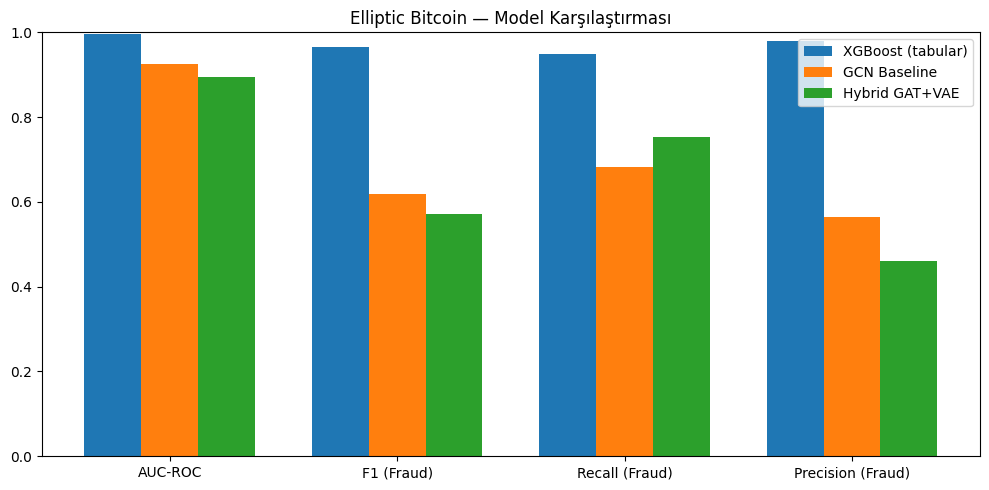

Graf kaydedildi.


In [16]:
results = pd.DataFrame({
    'Model': ['XGBoost (tabular)', 'GCN Baseline', 'Hybrid GAT+VAE'],
    'F1 (Fraud)':        [xgb_metrics['f1_fraud'],     gcn_metrics['f1_fraud'],     hybrid_metrics['f1_fraud']],
    'Recall (Fraud)':    [xgb_metrics['recall_fraud'], gcn_metrics['recall_fraud'], hybrid_metrics['recall_fraud']],
    'Precision (Fraud)': [xgb_metrics['precision_fraud'], gcn_metrics['precision_fraud'], hybrid_metrics['precision_fraud']],
    'AUC-ROC':           [xgb_metrics['roc_auc'],      gcn_metrics['roc_auc'],      hybrid_metrics['roc_auc']],
})

print(results.to_string(index=False))
results.to_csv('../results/tables/elliptic_results.csv', index=False)
print('\nKaydedildi: results/tables/elliptic_results.csv')

# Bar chart
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['AUC-ROC', 'F1 (Fraud)', 'Recall (Fraud)', 'Precision (Fraud)']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (model, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    ax.bar(x + idx*width, vals, width, label=row['Model'])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_title('Elliptic Bitcoin — Model Karşılaştırması')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/elliptic_comparison.png', dpi=150)
plt.show()
print('Graf kaydedildi.')


In [17]:
# Model kaydet
torch.save(model.state_dict(), '../results/models/hybrid_gatvae_elliptic.pt')
print('Model kaydedildi.')

AttributeError: 'int' object has no attribute 'state_dict'